# Answering Questions

*Note: I answered these questions under the assumption that they are supposed to be answered using the table created in part b (`std_member_info`).*

**The following questions were provided as part of the challenge:**
1. How many distinct members were eligible in April of 2025?
- **Answer:** There were 32576 distinct members eligible in April of 2025.
2. How many members were included more than once?
- **Answer:** There are 8130 members that were included more than once.
3. What is the breakdown of members by payer?

- **Answer:**
    | Payer Type | Number of Members |
    | ---------- | ----------------- |
    | Medicare Advantage | 14589 |
    | Medicaid | 24663 |

4. How many members live in a zip code with a `Food access score` less than 2? 
- **Answer:** There are 3038 members who live in zip codes with food access scores less than 2
5. What is the average `Social isolation score` for all members?
- **Answer:** The average social isolation score for all members is 3.070333995719963
6. Which members live in the zip code with the highest `Algorex SDOH composite score`?
- **Answer:** *Refer to dataframe `max_sdoh_members` dataframe under question 6 below.*

In [1]:
# Initialization things
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
# The db lives at the repo root, one level up from this notebooks/ folder
con = sqlite3.connect("../n1_data_ops_challenge.db")
cur = con.cursor()

std_member_info = pd.read_sql("SELECT * FROM std_member_info",con)

In [2]:
# Make sure we got the data.
std_member_info.shape

(47382, 11)

## Question 1
How many distinct members were eligible in April of 2025?

In [3]:
window_start = pd.Timestamp('2025-04-01')
window_end = pd.Timestamp('2025-04-30')

elig_start = pd.to_datetime(std_member_info['eligibility_start_date'])
elig_end = pd.to_datetime(std_member_info['eligibility_end_date'])

elig_04_2025 = std_member_info[(elig_start <= window_end) & (elig_end >= window_start)]

print(f"There were {elig_04_2025['member_id'].nunique()} distinct members eligible in April of 2025.")

There were 32576 distinct members eligible in April of 2025.


## Question 2
How many members were included more than once?

In [4]:
print(f"There are {std_member_info.duplicated().sum()} members that were included more than once.")

There are 8130 members that were included more than once.


In [5]:
# De-duping here to make it easier for later
std_member_info.drop_duplicates(inplace=True)

## Question 3
What is the breakdown of members by payer?

In [6]:
payer_counts = std_member_info.groupby('payer')['member_id'].count()
payer_counts

payer
Madv    14589
Mdcd    24663
Name: member_id, dtype: int64

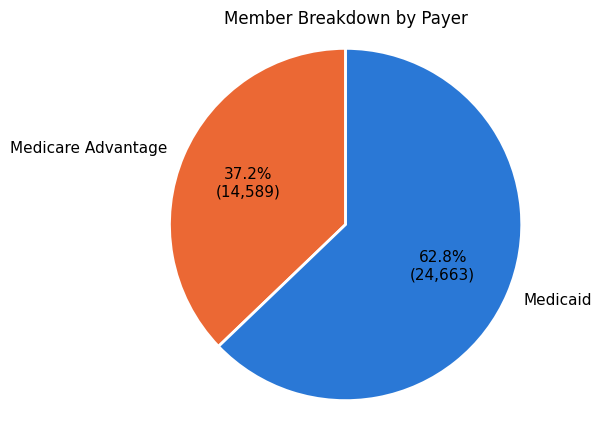

In [7]:
# Making a pie chart here. Might be useful for later.

payer_display = {'Mdcd': 'Medicaid', 'Madv': 'Medicare Advantage'}
payer_color = {'Mdcd': '#2a78d6', 'Madv': '#eb6834'}  # fixed per-payer color, independent of count/rank

labels = [payer_display[p] for p in payer_counts.index]
colors = [payer_color[p] for p in payer_counts.index]

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    payer_counts,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct / 100 * payer_counts.sum())):,})',
    colors=colors,
    startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    textprops={'fontsize': 11},
)
ax.set_title('Member Breakdown by Payer')
ax.axis('equal')
plt.show()

## Question 4
How many members live in a zip code with a `Food access score` less than 2? 

In [8]:
zips_under_2_sql = """
    SELECT DISTINCT zcta FROM model_scores_by_zip
    WHERE food_access_score < 2;
"""

zips_under_2 = pd.read_sql(zips_under_2_sql, con)['zcta'].tolist()
low_food_members = std_member_info[std_member_info['zip_code'].isin(zips_under_2)]
print(f"There are {low_food_members['member_id'].nunique()} members who live in zip codes with food access scores less than 2.")

There are 3038 members who live in zip codes with food access scores less than 2.


## Question 5
What is the average `Social isolation score` for all members?

In [9]:
iso_score_sql = """
    SELECT zcta, social_isolation_score FROM model_scores_by_zip;
"""

iso_score = pd.read_sql(iso_score_sql, con)
merged = pd.merge(std_member_info, iso_score, left_on='zip_code', right_on='zcta', how='left')
print(f"The average social isolation score for all members is {merged['social_isolation_score'].mean()}")

The average social isolation score for all members is 3.070333995719963


## Question 6
Which members live in the zip code with the highest `Algorex SDOH composite score`?

In [10]:
sdoh_score_sql = """
    SELECT zcta, algorex_sdoh_composite_score AS sdoh FROM model_scores_by_zip;
"""

sdoh_score = pd.read_sql(sdoh_score_sql, con)
merged = pd.merge(std_member_info, sdoh_score, left_on='zip_code', right_on='zcta', how='left')
max_sdoh_members = merged[merged['sdoh'] == max(merged['sdoh'])]
max_sdoh_members.drop('zcta', axis=1, inplace=True)

/var/folders/5h/v7kmvzmd5mg0kxqh1qpwf2bh0000gn/T/ipykernel_69089/3588175151.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_sdoh_members.drop('zcta', axis=1, inplace=True)


In [11]:
max_sdoh_members

,member_id,member_first_name,member_last_name,date_of_birth,main_address,city,state,zip_code,payer,eligibility_start_date,eligibility_end_date,sdoh
9481,15456560,Thomas,Falcon,1943-03-04,8764 Waller Underpass Apt. 396,South Bethanyview,California,95950,Madv,2021-10-01,2026-05-01,8.77
9589,15462579,Tina,Davis,1999-09-23,988 Brown Manor,New Charles,California,95950,Madv,2021-10-01,2026-04-01,8.77
13723,15482255,Jessica,Hallock,1951-01-11,12036 David Walk,North Vickibury,California,95950,Madv,2021-11-01,2026-02-01,8.77
13763,15484216,Antonio,Riley,1967-09-30,5666 Christy Ways,East Cathy,California,95950,Mdcd,2021-11-01,2026-04-01,8.77
14656,15532243,William,Munoz,1990-05-08,50928 Martin Shores Suite 815,West Melissafort,California,95950,Madv,2021-11-01,2026-04-01,8.77
15161,15359217,Jessie,Rowe,1988-02-19,40915 Richardson Crescent,North Jeffrey,California,95950,Madv,2021-12-01,2025-05-01,8.77
17776,15493624,Jerry,Vandermeer,1927-04-04,2798 Mcgrath Mountains Apt. 112,Rodriguezburgh,California,95950,Mdcd,2021-12-01,2025-09-01,8.77
19798,15389759,Denise,Hawthorne,1957-02-10,65788 Burnett Highway,South Tanyaburgh,California,95950,Madv,2022-01-01,2025-08-01,8.77
21203,15459547,Kenneth,Prather,1944-09-03,3210 David Alley,North Benjamin,California,95950,Mdcd,2022-01-01,2026-01-01,8.77
21936,15495072,Eric,Howard,1947-07-16,400 Lee Plaza,Marquezton,California,95950,Mdcd,2022-01-01,2026-03-01,8.77
